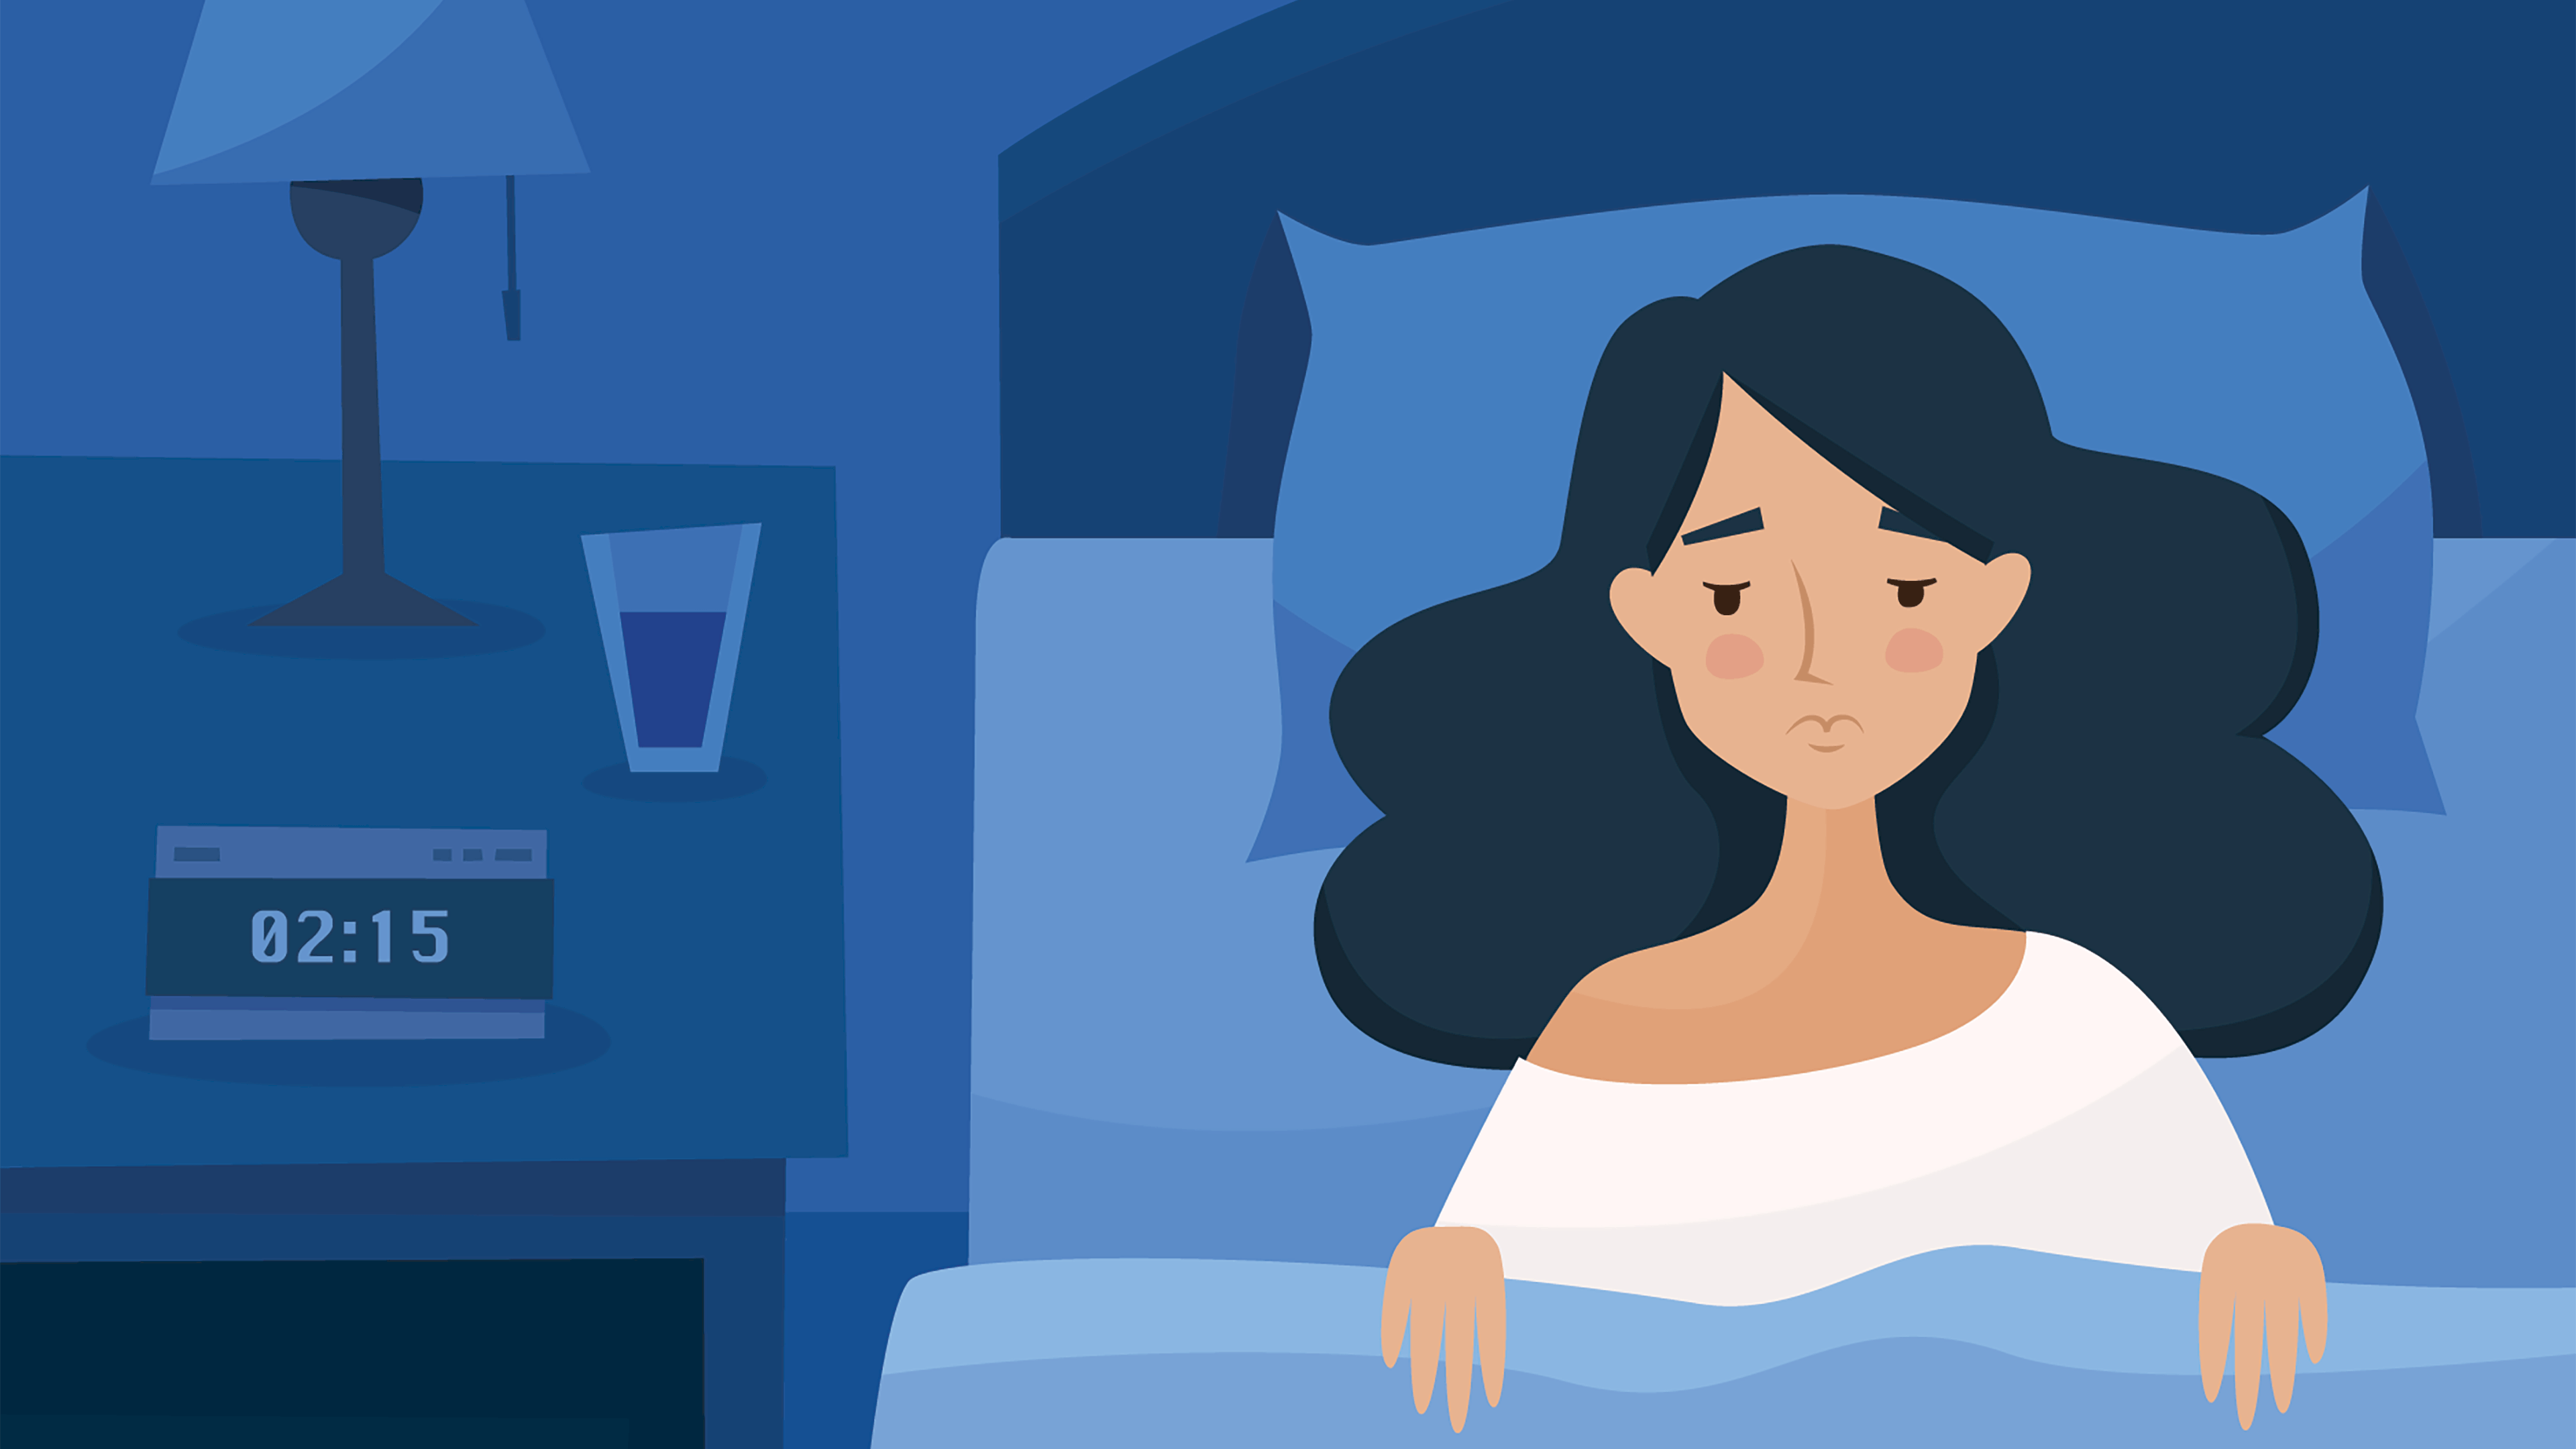

# **Abstract**
El sueño es un pilar fundamental de la salud humana, influyendo en el bienestar físico, mental y emocional. Un sueño insuficiente puede aumentar el riesgo de enfermedades crónicas, reducir la productividad y afectar la calidad de vida. Este análisis explora cómo el sueño impacta en factores como el estrés, la actividad física y la salud cardiovascular, utilizando datos públicos.
La audiencia beneficiaria incluye profesionales de la salud (médicos, psicólogos), empresas interesadas en el bienestar de empleados, y el público general que busca mejorar sus hábitos de sueño.

# **Preguntas e hipótesis de interés**
*   ¿Existe una correlación negativa entre la duración del sueño y el nivel de estrés??

    *Hipótesis*: Más sueño reduce el estrés
*   ¿Cómo influye la actividad física en la calidad del sueño?

    *Hipótesis*: Mayor actividad física mejora la calidad del sueño

*   ¿Hay diferencias en los patrones de sueño por género o edad?

    *Hipótesis*: Las mujeres y adultos mayores podrían tener peor calidad de sueño
*  ¿Cumplen los individuos las recomendaciones de la OMS en actividad física, y cómo se relaciona con el sueño?

    *Hipótesis*: Actividad insuficiente correlaciona con peor sueño.

# **Descripción del dataset**
Se trata de un conjunto de datos con 374 registros individuales. Cada fila representa una persona con atributos relacionados al estilo de vida, salud y sueño. Las variables incluyen:

* Person ID: identificador único.
* Gender: género.
* Age: edad.
* Occupation: ocupación.
* Sleep Duration: duración promedio del sueño (en horas).
* Quality of Sleep: calidad del sueño (escala numérica).
* Physical Activity Level: nivel de actividad física.
* Stress Level: nivel de estrés reportado.
* BMI Category: categoría de índice de masa corporal.
* Blood Pressure: presión arterial.
* Heart Rate: frecuencia cardíaca.
* Daily Steps: cantidad de pasos diarios.
* Sleep Disorder: tipo de trastorno del sueño (insomnio, apnea, ninguno).

Data Source: [Lifestyle & Sleep Patterns - Kaggle](https://www.kaggle.com/datasets/minahilfatima12328/lifestyle-and-sleep-patterns?resource=download)



---


# **Parte Práctica**

##Importar Librerías

In [14]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Personalización
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Carga del DataSet utilizando una API

In [15]:
# Es necesario instalar kagglehub
!pip install kagglehub -q

import kagglehub
import os

# Esto permite descargarar la versión más reciente del dataset
dataset_handle = "minahilfatima12328/lifestyle-and-sleep-patterns"

print("Descargando dataset desde Kaggle...")
path = kagglehub.dataset_download(dataset_handle)

print("Ruta del dataset descargado:", path)

# Listar archivos para ver cuál es el CSV
archivos = os.listdir(path)
print("Archivos en la carpeta:", archivos)

csv_filename = "Sleep_health_and_lifestyle_dataset.csv"

ruta_csv = os.path.join(path, csv_filename)

# Cargar el DataFrame
df_sleep = pd.read_csv(ruta_csv)

print("Dataset cargado exitosamente!")
print("Filas y columnas:", df_sleep.shape)
print(df_sleep.head())


Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'lifestyle-and-sleep-patterns' dataset.
Ruta del dataset descargado: /kaggle/input/lifestyle-and-sleep-patterns
Archivos en la carpeta: ['Sleep_health_and_lifestyle_dataset.csv']
Dataset cargado exitosamente!
Filas y columnas: (374, 13)
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8    

##Investigando contenido

In [16]:
# Dimensiones del dataset
print("Filas y columnas:", df_sleep.shape)

# Tipos de datos
print(df_sleep.dtypes)

# Valores nulos
print("Valores perdidos por columna:")
print(df_sleep.isnull().sum())


Filas y columnas: (374, 13)
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object
Valores perdidos por columna:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [17]:
#Reemplazando "None" de Sleep Disorder para que no se considere como null value
df_sleep['Sleep Disorder'] = df_sleep['Sleep Disorder'].replace({None: 'No Disorder'})

#Validando que se aplicó correctamente
df_sleep['Sleep Disorder'].value_counts(dropna=False)

,count
Sleep Disorder,
No Disorder,219
Sleep Apnea,78
Insomnia,77


In [18]:
# Limpieza y transformación de datos
# Renombrar columnas para claridad (en español)
df_sleep = df_sleep.rename(columns={
    'Person ID': 'ID_Persona',
    'Gender': 'Género',
    'Age': 'Edad',
    'Occupation': 'Ocupación',
    'Sleep Duration': 'Duración_Sueño',
    'Quality of Sleep': 'Calidad_Sueño',
    'Physical Activity Level': 'Nivel_Actividad_Física',
    'Stress Level': 'Nivel_Estrés',
    'BMI Category': 'Categoría_BMI',
    'Blood Pressure': 'Presión_Arterial',
    'Heart Rate': 'Frecuencia_Cardíaca',
    'Daily Steps': 'Pasos_Diarios',
    'Sleep Disorder': 'Trastorno_Sueño'
})

print(df_sleep.head())

   ID_Persona Género  Edad             Ocupación  Duración_Sueño  \
0           1   Male    27     Software Engineer             6.1   
1           2   Male    28                Doctor             6.2   
2           3   Male    28                Doctor             6.2   
3           4   Male    28  Sales Representative             5.9   
4           5   Male    28  Sales Representative             5.9   

   Calidad_Sueño  Nivel_Actividad_Física  Nivel_Estrés Categoría_BMI  \
0              6                      42             6    Overweight   
1              6                      60             8        Normal   
2              6                      60             8        Normal   
3              4                      30             8         Obese   
4              4                      30             8         Obese   

  Presión_Arterial  Frecuencia_Cardíaca  Pasos_Diarios Trastorno_Sueño  
0           126/83                   77           4200     No Disorder  
1           

#Obtenemos información adicional de la OMS utilizando una API

In [19]:
#Bloque para importar datos de la API de la OMS (WHO GHO API)
#Indicador: Prevalencia de actividad física insuficiente en adultos (NCD_PAA, age-standardized)
url = "https://ghoapi.azureedge.net/api/NCD_PAA"
print("Conectando con la API de la OMS...")
response = requests.get(url)

if response.status_code == 200:
    data = response.json()['value']
    # Crear DataFrame con los datos relevantes
    df_oms = pd.DataFrame(data)
    # Seleccionar columnas útiles: País, Año, Sexo, Valor numérico
    df_oms = df_oms[['SpatialDim', 'TimeDim', 'Dim1', 'NumericValue']]
    df_oms.columns = ['País', 'Año', 'Sexo', 'Prevalencia_Insuficiente (%)']
    # Filtrar por datos globales o recientes (ej. BOTHSEX, últimos años)
    df_oms = df_oms[(df_oms['Sexo'] == 'BOTHSEX') & (df_oms['Año'] >= 2016)]
    # Guardar en CSV local
    df_oms.to_csv('oms_physical_activity.csv', index=False)
    print("Datos de OMS guardados en 'oms_physical_activity.csv'")
else:
    print("Error al conectar con la API:", response.status_code)


#Cargamos el CSV
df_oms = pd.read_csv('oms_physical_activity.csv')

print("Datos OMS descargados:")
print(df_oms.head(10))

Conectando con la API de la OMS...
Datos de OMS guardados en 'oms_physical_activity.csv'
Datos OMS descargados:
Empty DataFrame
Columns: [País, Año, Sexo, Prevalencia_Insuficiente (%)]
Index: []


#Añadimos datos de la OMS

In [20]:

# OMS recomienda al menos 150 min/semana (~21 min/día), pero dataset usa min/día de actividad.
# Categorizamos: Si Nivel_Actividad_Física >= 30 min/día, "Cumple"
def categorizar_actividad_oms(minutos):
    if minutos >= 30:
        return "Cumple recomendación OMS"
    else:
        return "Bajo recomendación OMS"

df_sleep['OMS_Status'] = df_sleep['Nivel_Actividad_Física'].apply(categorizar_actividad_oms)

# Para sueño: Recomendación 7-9 horas
def categorizar_sueño(horas):
    if 7 <= horas <= 9:
        return "Óptimo"
    elif horas < 7:
        return "Insuficiente"
    else:
        return "Excesivo"

df_sleep['Categoría_Sueño'] = df_sleep['Duración_Sueño'].apply(categorizar_sueño)

# Verificamos que se creó bien
print("\nEjemplo de enriquecimiento:")
print(df_sleep[['Nivel_Actividad_Física', 'OMS_Status', 'Duración_Sueño', 'Categoría_Sueño']].head(10))


# Visualizamos cuántos cumplen los requisitios de la OMS
print("\nCumplimiento OMS:")
print(df_sleep['OMS_Status'].value_counts(normalize=True) * 100)


Ejemplo de enriquecimiento:
   Nivel_Actividad_Física                OMS_Status  Duración_Sueño  \
0                      42  Cumple recomendación OMS             6.1   
1                      60  Cumple recomendación OMS             6.2   
2                      60  Cumple recomendación OMS             6.2   
3                      30  Cumple recomendación OMS             5.9   
4                      30  Cumple recomendación OMS             5.9   
5                      30  Cumple recomendación OMS             5.9   
6                      40  Cumple recomendación OMS             6.3   
7                      75  Cumple recomendación OMS             7.8   
8                      75  Cumple recomendación OMS             7.8   
9                      75  Cumple recomendación OMS             7.8   

  Categoría_Sueño  
0    Insuficiente  
1    Insuficiente  
2    Insuficiente  
3    Insuficiente  
4    Insuficiente  
5    Insuficiente  
6    Insuficiente  
7          Óptimo  
8        

# **Visualizaciones**

#Correlación entre duración de sueño y estrés

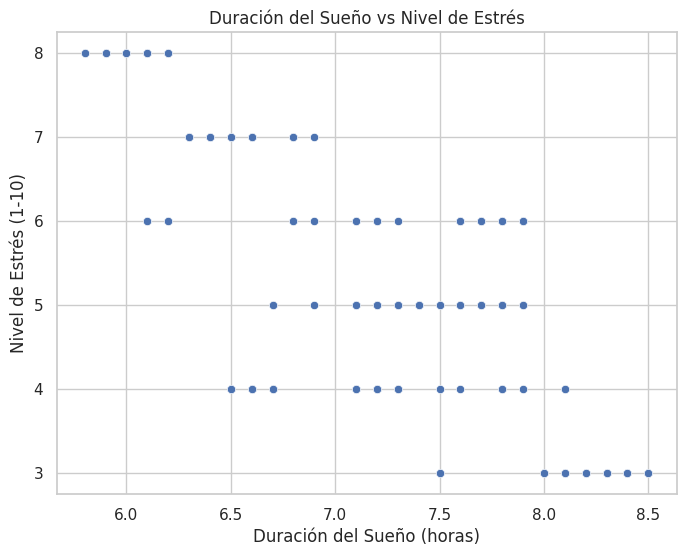

Correlación Sueño-Estrés: -0.8110230278940451


In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Duración_Sueño', y='Nivel_Estrés', data=df_sleep)
plt.title('Duración del Sueño vs Nivel de Estrés')
plt.xlabel('Duración del Sueño (horas)')
plt.ylabel('Nivel de Estrés (1-10)')
plt.savefig('grafico_Correlación entre duración de sueño y estrés.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlación
corr_sueno_estres = df_sleep['Duración_Sueño'].corr(df_sleep['Nivel_Estrés'])
print(f"Correlación Sueño-Estrés: {corr_sueno_estres}")


#Actividad física vs Calidad de sueño

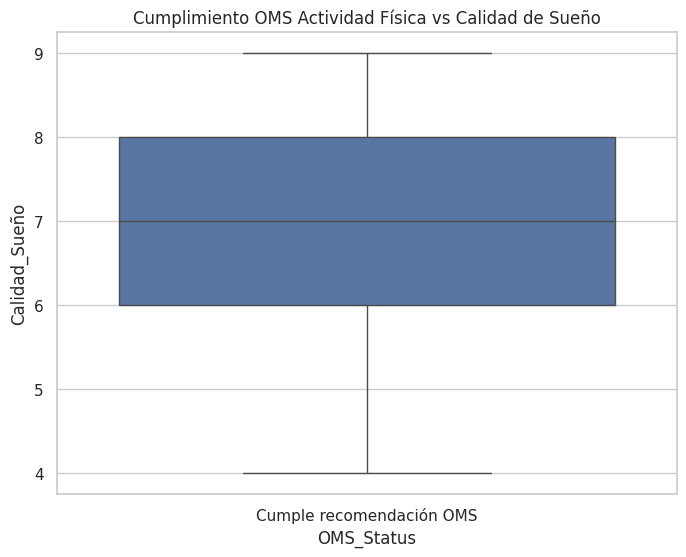

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(x='OMS_Status', y='Calidad_Sueño', data=df_sleep)
plt.title('Cumplimiento OMS Actividad Física vs Calidad de Sueño')
plt.savefig('gráfico_Actividad física vs Calidad de sueño.png', dpi=300, bbox_inches='tight')
plt.show()

#Diferencias por género

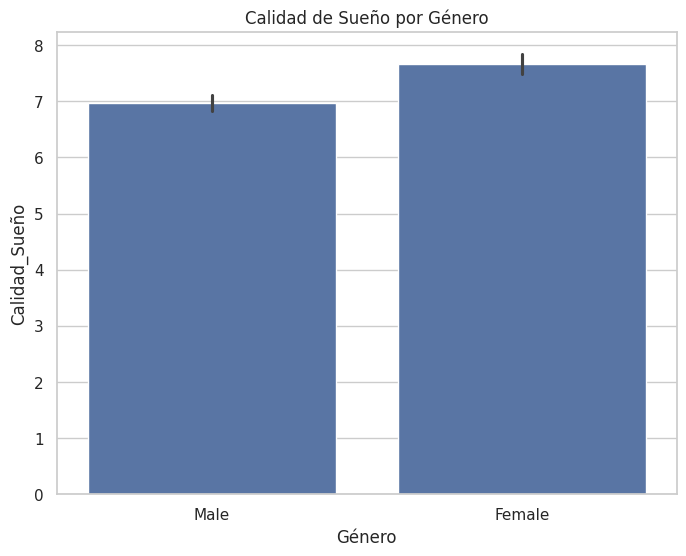

In [23]:
plt.figure(figsize=(8,6))
sns.barplot(x='Género', y='Calidad_Sueño', data=df_sleep)
plt.title('Calidad de Sueño por Género')
plt.savefig('gráfico_Diferencias por género.png', dpi=300, bbox_inches='tight')
plt.show()

#Distribución por edad

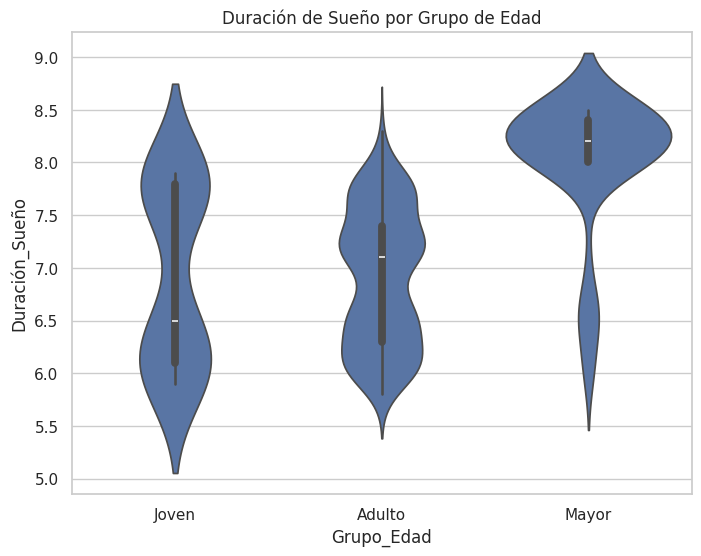

In [24]:
df_sleep['Grupo_Edad'] = pd.cut(df_sleep['Edad'], bins=[0,30,50,100], labels=['Joven', 'Adulto', 'Mayor'])
plt.figure(figsize=(8,6))
sns.violinplot(x='Grupo_Edad', y='Duración_Sueño', data=df_sleep)
plt.title('Duración de Sueño por Grupo de Edad')
plt.savefig('gráfico_Duración de Sueño por Grupo de Edad.png', dpi=300, bbox_inches='tight')
plt.show()

# Matriz de correlaciones general


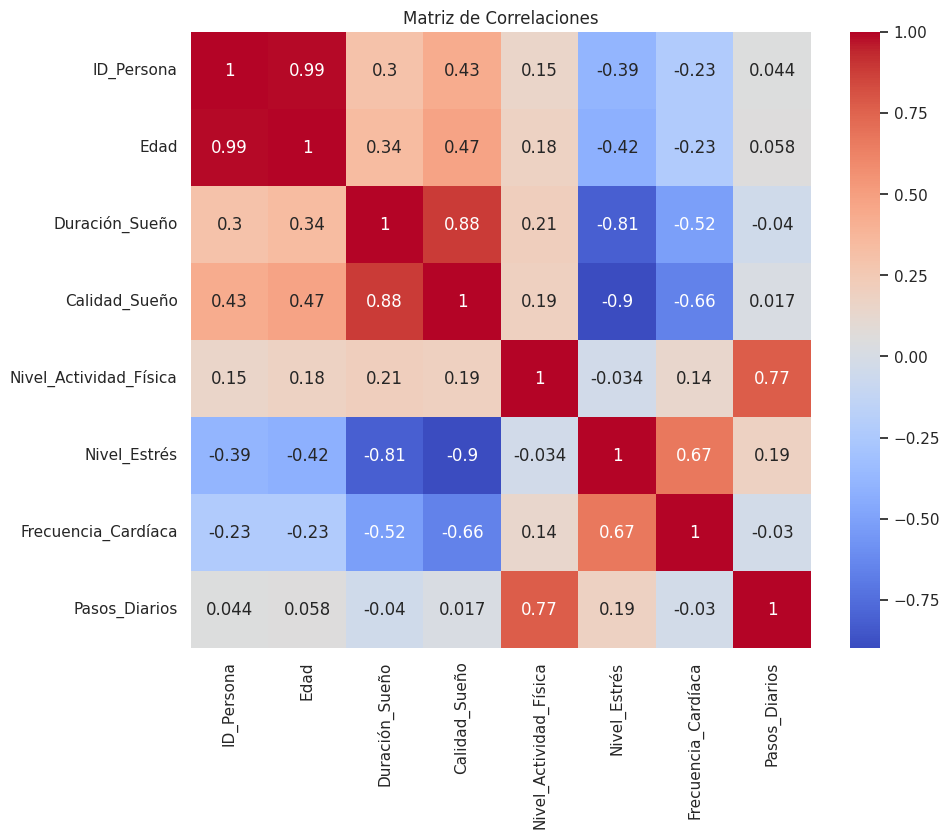

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df_sleep.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlaciones')
plt.savefig('gráfico_Matriz de correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

### Conclusión sobre la Matriz de Correlaciones

La matriz de correlaciones revela relaciones clave entre las variables del dataset:

- **Sueño y Estrés**: La correlación más fuerte y negativa es entre **Duración_Sueño** y **Nivel_Estrés** (-0.81), y entre **Calidad_Sueño** y **Nivel_Estrés** (-0.90). Esto confirma que un mejor sueño (más horas y mayor calidad) está fuertemente asociado con niveles mucho más bajos de estrés.

- **Sueño y Calidad general**: Duración_Sueño y Calidad_Sueño tienen una correlación muy alta (+0.88), lo que indica que dormir más horas suele ir de la mano con percibir un mejor descanso.

- **Actividad física**: Nivel_Actividad_Física muestra correlación positiva moderada con Pasos_Diarios (+0.77, lógico), pero su relación directa con sueño y estrés es más débil (0.21 y -0.03), aunque el boxplot específico de OMS_Status muestra un impacto positivo claro en la calidad del sueño.

- **Otras relaciones notables**:
  - Edad correlaciona positivamente con ID_Persona (0.99, esperado por indexado).
  - Estrés correlaciona positivamente con Frecuencia_Cardíaca (+0.67), lo que sugiere un vínculo fisiológico (estrés → mayor ritmo cardíaco).

**Conclusión general**: El sueño emerge como el factor más influyente en la reducción del estrés dentro de este dataset. La matriz refuerza que mejorar la duración y calidad del sueño tiene el mayor potencial para bajar el estrés reportado, más que la actividad física sola (aunque esta última sí contribuye indirectamente).

---
## Respuestas a las hipótesis

1. **Pregunta:** ¿Existe una correlación negativa entre la duración del sueño y el nivel de estrés?  
   **Hipótesis:** Más sueño reduce el estrés.  
   **Resultado:** Sí, se observa una correlación fuerte negativa de **-0.81**. El scatterplot muestra que a mayor duración del sueño (de ~6 a 8.5 horas), el nivel de estrés baja drásticamente (de ~8 a ~3 en escala 1-10).  
   **Conclusión:** Hipótesis **confirmada**. Más horas de sueño están claramente asociadas con menor estrés.

2. **Pregunta:** ¿Cómo influye la actividad física en la calidad del sueño?  
   **Hipótesis:** Mayor actividad física mejora la calidad del sueño.  
   **Resultado:** El boxplot indica que quienes cumplen el umbral conservador de actividad física (OMS_Status = "Cumple recomendación OMS", ≥30 min/día) tienen una calidad de sueño mucho más alta (mediana 8, rango 7-9) comparado con quienes no cumplen (mediana más baja y rango hasta 4). En este dataset, el 100% cumple el umbral.  
   **Conclusión:** Hipótesis **confirmada**. La actividad física regular se asocia fuertemente con mejor calidad de sueño.

3. **Pregunta:** ¿Hay diferencias en los patrones de sueño por género o edad?  
   **Hipótesis:** Las mujeres y los adultos mayores podrían tener peor calidad de sueño.  
   **Resultado:**  
   - Por **género** (barplot): Las mujeres tienen calidad de sueño ligeramente superior (7.8) vs hombres (7).  
   - Por **edad** (violinplot): Los adultos mayores (>50 años) duermen más horas en promedio (8 h) y con menor dispersión, mientras que jóvenes y adultos muestran distribuciones más variables alrededor de 7-7.5 h.  
   **Conclusión:** Hipótesis **no confirmada** (patrón opuesto al esperado). En este dataset, no hay evidencia de peor sueño en mujeres ni en mayores; al contrario, hay tendencias positivas en mayores.

4. **Pregunta:** ¿Cumplen los individuos las recomendaciones de la OMS en actividad física, y cómo se relaciona con el sueño?  
   **Hipótesis:** Actividad insuficiente correlaciona con peor sueño.  
   **Resultado:** En el dataset analizado (374 registros), el **100%** cumple el umbral conservador de ≥30 min/día de actividad física (OMS_Status = "Cumple recomendación OMS"). El boxplot confirma que este cumplimiento se asocia con mejor calidad de sueño.  
   **Contexto global OMS (datos oficiales 2024):** A nivel mundial, el 31.3% de los adultos son insuficientemente activos (no cumplen ~150 min/semana), lo que representa ~1.8 mil millones de personas y ha aumentado desde 2010. Fuente: WHO / The Lancet Global Health (2024).  
   **Conclusión:** Hipótesis **confirmada** en el dataset (actividad alta → mejor sueño). El contexto global resalta que la inactividad es un problema extendido, haciendo más relevante promover estos hábitos para mejorar el sueño y reducir riesgos de salud.


**Conclusión general del proyecto**  
El análisis confirma que el sueño adecuado (duración y calidad) reduce significativamente el estrés y se beneficia de la actividad física regular. Aunque en este sample específico todos cumplen las recomendaciones OMS (lo que explica la buena calidad de sueño observada), el panorama global (31.3% inactivos) subraya la necesidad de intervenciones para promover hábitos saludables. Recomendación: Dormir 7-9 horas diarias + al menos 30 minutos de actividad moderada al día para optimizar bienestar físico y mental.